u - the model's mean/drift parameter for the stock's underlying process
p - Persistence of volatility - controls how much the current volatility state ht carries over into the next period
v - volatility of the volatility process - controls how much random shock can change ht
S0 - initial stock price
h0 - initial volatility-state value

h1 - Model's hidden volatility state
p - determines how much yesterday's ht influences tomorrow
e^ht - converts that state into the actual volatility multiplying the stock shock

K - strike price of the call option
n - number of time periods until expiration
B - Discount factor per period


In [2]:
default_u = 0.0001
default_p = 0.1
default_v = 0.001
default_s0 = 10
default_h0 = 0

default_K = 100
default_n = 10
default_B = 0.95

In [3]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()

def simulate_asset_price_path(u=default_u, s0=default_s0, h0=default_h0, n=default_n, p=default_p, v=default_v, rng=rng):
    s = np.empty(n+1)
    s[0] = np.log(s0)

    h = h0
    for t in range(n):
        s[t+1] = s[t] + u + np.exp(h) * rng.standard_normal()
        h = p * h + v * rng.standard_normal()

    return np.exp(s)


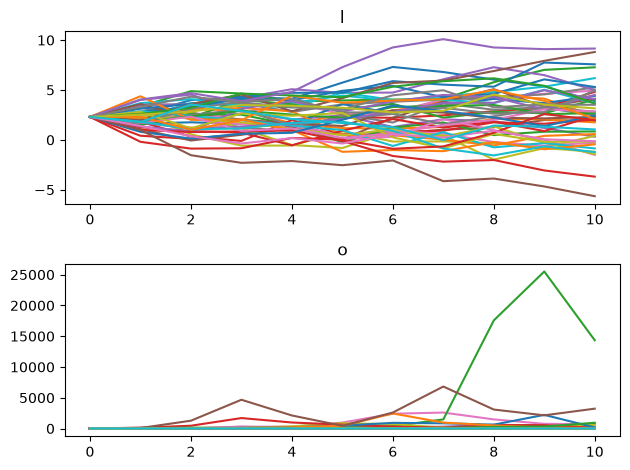

In [ ]:
fig, axes = plt.subplots(2, 1)

titles = 'log paths', 'paths'
transforms = np.log, lambda x: x
for ax, transform, title in zip(axes, transforms, titles):
    for i in range(50):
        path = simulate_asset_price_path()
        ax.plot(transform(path))
    ax.set_title(title)

fig.tight_layout()
plt.show()


In [ ]:
def compute_call_price(B=default_B, u=default_u,
                       s0=default_s0, h0=default_h0,
                       K = default_K, n = default_n,
                       p = default_p, v = default_v,
                       M=10000,
                       rng=rng):
        current_sum = 0.0

        # For each sample path
        for m in range(M):
            s = np.log(50)
            h = h0

            # Simulate forward in time
            for t in range(n):
                s = s + u + np.exp(h) * rng.standard_normal()
                h = p * h + v * rng.standard_normal()
            # And add the value max{S_n - K, 0} to current_sum
            current_sum += np.maximum(np.exp(s) - K, 0)

        return B**n * current_sum / M

In [7]:
%%time
compute_call_price()

CPU times: total: 125 ms
Wall time: 141 ms


np.float64(3170.880852812841)